In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_training = pd.read_csv("../data_csv/training_data_all_images.csv")
df_training.head()

,glyph_image,elements_original,full_image_path,20,21?,?,??,?_01,?_02,?_03,...,zacatl,zacuan,zahualli,zahuatl,zayolin,zo,zolin,zoquitl,zoyatl,zozoma
0,026r_A_01-2.jpg,xilotl,All_images/t_026\026r_A_01.jpg,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,026r_A_02-2.jpg,miztli|xayacatl,All_images/t_026\026r_A_02.jpg,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,026r_A_05-2.jpg,ocelotl,All_images/t_026\026r_A_05.jpg,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,026r_A_06-2.jpg,tepetl|tlalli,All_images/t_026\026r_A_06.jpg,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,026r_A_07-2.jpg,atl|apantli,All_images/t_026\026r_A_07.jpg,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
len(df_training)

21952

In [4]:
df = pd.read_csv("../runs/run_10/per_label_metrics.csv")
df.head()

,label,true_positives,false_positives,false_negatives,precision,recall,f1
0,?,0,1,95,0.00,0.00000,0.000000
1,?_02,0,0,5,0.00,0.00000,0.000000
2,?_03,0,0,17,0.00,0.00000,0.000000
3,?_04,0,0,7,0.00,0.00000,0.000000
4,?_05,1,3,40,0.25,0.02439,0.044444


In [5]:
df.sort_values("f1", ascending=False, inplace=True)
df

,label,true_positives,false_positives,false_negatives,precision,recall,f1
220,totolteme,17,0,0,1.000000,1.000000,1.000000
167,tejuelo_1,4,0,0,1.000000,1.000000,1.000000
19,carga_de_yerba,15,0,1,1.000000,0.937500,0.967742
23,cemixtlapalli,42,3,0,0.933333,1.000000,0.965517
52,cuahuacalli,25,0,2,1.000000,0.925926,0.961538
...,...,...,...,...,...,...,...
62,cuetlachtli,0,0,9,0.000000,0.000000,0.000000
63,cuetlaxtli,0,0,3,0.000000,0.000000,0.000000
66,cuezalin,0,0,4,0.000000,0.000000,0.000000
164,tecolotl,0,0,5,0.000000,0.000000,0.000000


In [6]:
df.count()

label              259
true_positives     259
false_positives    259
false_negatives    259
precision          259
recall             259
f1                 259
dtype: int64

Text(0.5, 1.0, 'Histogram of F1 Scores')

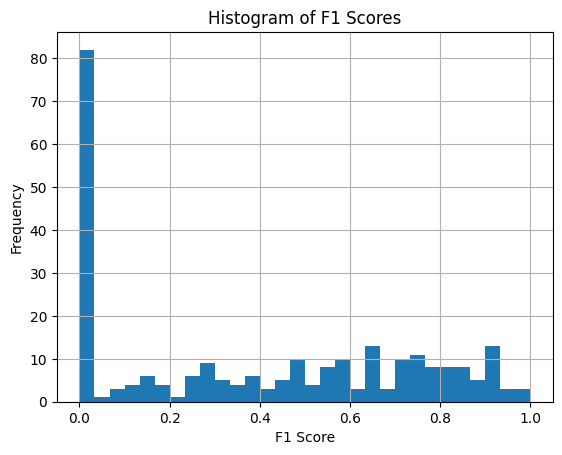

In [7]:
df["f1"].hist(bins=30)
plt.xlabel("F1 Score")
plt.ylabel("Frequency")
plt.title("Histogram of F1 Scores")

In [8]:
df[df["f1"] <= 0.49999].sort_values("f1", ascending=False)


,label,true_positives,false_positives,false_negatives,precision,recall,f1
201,tlantli,23,19,28,0.547619,0.450980,0.494624
207,tlatoa,19,10,32,0.655172,0.372549,0.475000
51,cuacuahuitl,4,0,9,1.000000,0.307692,0.470588
159,quetzalli,23,17,35,0.575000,0.396552,0.469388
91,itzcuintli,10,5,18,0.666667,0.357143,0.465116
...,...,...,...,...,...,...,...
3,?_04,0,0,7,0.000000,0.000000,0.000000
224,tzacualli,0,0,7,0.000000,0.000000,0.000000
2,?_03,0,0,17,0.000000,0.000000,0.000000
8,amatl,0,1,13,0.000000,0.000000,0.000000


In [9]:
df[df["f1"] > 0.499999].sort_values("f1", ascending=True)

,label,true_positives,false_positives,false_negatives,precision,recall,f1
77,huehuetl,1,0,2,1.000000,0.333333,0.500000
251,yacametztli,2,2,2,0.500000,0.500000,0.500000
105,malinalli,2,0,4,1.000000,0.333333,0.500000
61,cueitl,6,2,10,0.750000,0.375000,0.500000
110,matlatl,3,0,6,1.000000,0.333333,0.500000
...,...,...,...,...,...,...,...
52,cuahuacalli,25,0,2,1.000000,0.925926,0.961538
23,cemixtlapalli,42,3,0,0.933333,1.000000,0.965517
19,carga_de_yerba,15,0,1,1.000000,0.937500,0.967742
167,tejuelo_1,4,0,0,1.000000,1.000000,1.000000


In [10]:
low_f1 = df[df["f1"] <= 0.49999].sort_values("f1", ascending=False).label.tolist()
df[df["f1"] <= 0.49999].apply(lambda x: print(f"Name: {x['label']}, F1: {x['f1']}, Total: {x['true_positives'] + x['false_negatives']}"), axis=1)

Name: tlantli, F1: 0.494623650854434, Total: 51
Name: tlatoa, F1: 0.4749999952593751, Total: 51
Name: cuacuahuitl, F1: 0.4705882311418685, Total: 13
Name: quetzalli, F1: 0.469387750174927, Total: 58
Name: itzcuintli, F1: 0.4651162743104381, Total: 28
Name: cimatl, F1: 0.4615384572781065, Total: 10
Name: xahualli, F1: 0.4499999962875, Total: 31
Name: tlaloc, F1: 0.44444444, Total: 7
Name: popoca, F1: 0.4444444392798353, Total: 27
Name: cuixtli, F1: 0.4285714241836735, Total: 20
Name: eztli, F1: 0.4210526278116344, Total: 15
Name: xayacatl, F1: 0.4074074036008231, Total: 41
Name: huitztli, F1: 0.399999996192, Total: 38
Name: etl, F1: 0.39999999585, Total: 15
Name: xacalli, F1: 0.3999999952, Total: 4
Name: cuecuextli, F1: 0.3999999952, Total: 4
Name: maxtlatl, F1: 0.3846153793491125, Total: 14
Name: teoxihuitl, F1: 0.3703703651028807, Total: 14
Name: nextli, F1: 0.36363636, Total: 9
Name: xolotl, F1: 0.36363636, Total: 9
Name: casa, F1: 0.3636363583471075, Total: 4
Name: xolochauhqui, F1:

201    None
207    None
51     None
159    None
91     None
       ... 
62     None
63     None
66     None
164    None
0      None
Length: 143, dtype: object

In [11]:
df_rel = pd.read_csv("../data_csv/relationships_updated.csv")
df_rel.head()

,Unnamed: 0,codex_id,codex_titre,glyph_id,glyph_cote,glyph_lecture,element_id,element_name,element_theme,glyph_image
0,0,1,XOLOTL,1.0,X.010.A.01,tenamitec,584,tetl,04.04.01,X.010.A.01-1.jpg
1,1,1,XOLOTL,1.0,X.010.A.01,tenamitec,747,xocpalmachiyotl,01.04.03,X.010.A.01-1.jpg
2,2,1,XOLOTL,2.0,X.010.A.03,cuauhchinanco,472,petlatl,05.02.03,X.010.A.03-1.jpg
3,3,1,XOLOTL,2.0,X.010.A.03,cuauhchinanco,193,cuahuitl_1,03.01.01,X.010.A.03-1.jpg
4,4,1,XOLOTL,2.0,X.010.A.03,cuauhchinanco,161,comitl,05.03.01,X.010.A.03-1.jpg


In [12]:
df_rel[df_rel["element_name"] == "tlantli"]

,Unnamed: 0,codex_id,codex_titre,glyph_id,glyph_cote,glyph_lecture,element_id,element_name,element_theme,glyph_image
287,287,1,XOLOTL,134.0,X.010.I.12,...tla...,628,tlantli,01.02.19,X.010.I.12-1.jpg
318,318,1,XOLOTL,151.0,X.010.I.35,NaN,628,tlantli,01.02.19,X.010.I.35-1.jpg
351,351,1,XOLOTL,162.0,X.011.A.09-,? ixpan,628,tlantli,01.02.19,X.011.A.09-1.jpg
405,405,1,XOLOTL,194.0,X.011.D.13-,NaN,628,tlantli,01.02.19,X.011.D.13-1.jpg
407,407,1,XOLOTL,195.0,X.011.D.15,NaN,628,tlantli,01.02.19,X.011.D.15-1.jpg
...,...,...,...,...,...,...,...,...,...,...
39685,39685,44,CUAUHTINCHAN 2,24140.0,MC2_B_038,tzitzimatlauhco,628,tlantli,01.02.19,MC2_B_038-44.jpg
40446,40446,44,CUAUHTINCHAN 2,24444.0,MC2_G_074,atlan *,628,tlantli,01.02.19,MC2_G_074-44.jpg
40618,40618,44,CUAUHTINCHAN 2,24509.0,MC2_H_072,xaltepec huetz malloyo iyacac *,628,tlantli,01.02.19,MC2_H_072-44.jpg
42977,42977,18,TELLERIANO,25465.0,385_21v_11_09,icue iomiyo itlan : itzpapalotl,628,tlantli,01.02.19,385_21v_11_09-18.jpg


In [17]:
img_element = {}


for label in low_f1:
    relations = df_rel[df_rel["element_name"] == label].copy()
    print(f"Element: {label}")
    img_element[label] = [v for v in relations["image_name"].tolist()]
    print(img_element)

Element: tlantli


KeyError: 'image_name'

In [14]:
relations

,Unnamed: 0,codex_id,codex_titre,glyph_id,glyph_cote,glyph_lecture,element_id,element_name,element_theme,glyph_image
6018,6018,8,ASUNCIóN,2933.0,A31r_3_A,?,3,?,09.09.09,A31r_3_A-8.jpg
6031,6031,8,ASUNCIóN,2939.0,A31v_4_B,temacoc,3,?,09.09.09,A31v_4_B-8.jpg
6105,6105,8,ASUNCIóN,2967.0,A35r_2_A,?,3,?,09.09.09,A35r_2_A-8.jpg
6158,6158,8,ASUNCIóN,2987.0,A38v_1_A,xochitepi,3,?,09.09.09,A38v_1_A-8.jpg
6164,6164,8,ASUNCIóN,2990.0,A38v_4_A,?,3,?,09.09.09,A38v_4_A-8.jpg
...,...,...,...,...,...,...,...,...,...,...
38760,38760,50,TOTOMIXTLAHUACAN,23523.0,T_C_033a,borrado,3,?,09.09.09,T_C_033a-50.jpg
38766,38766,50,TOTOMIXTLAHUACAN,NaN,T_C_036c,NaN,3,?,09.09.09,T_C_036c-50.jpg
38808,38808,50,TOTOMIXTLAHUACAN,23555.0,T_C_070a,cacalopanoc,3,?,09.09.09,T_C_070a-50.jpg
39458,39458,14,TOTOQUIHUAZTLI,24049.0,115_11_18,tziuhtepec,3,?,09.99.10,115_11_18-14.jpg
